## Chronic Kidney Disease Data Ingestion and Preprocessing 
*Dataset 3*

In [ ]:
#Installing all require libraries
%pip install pandas
%pip install numpy
%pip install matplotlib

In [2]:
#Required libraries
import os

import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt

# Load Dataset

In [3]:
# Paths
RAW_DATA_PATH = Path("../../data/raw/dataset_3.csv")

df = pd.read_csv(RAW_DATA_PATH)
if df is not None:
    print("Dataset 3 loaded successfully.")
else:
    print("Failed to load Dataset 3.")
df.head()

Dataset 3 loaded successfully.


,Age of the patient,Blood pressure (mm/Hg),Specific gravity of urine,Albumin in urine,Sugar in urine,Red blood cells in urine,Pus cells in urine,Pus cell clumps in urine,Bacteria in urine,Random blood glucose level (mg/dl),...,Smoking status,Body Mass Index (BMI),Physical activity level,Duration of diabetes mellitus (years),Duration of hypertension (years),Cystatin C level,Urinary sediment microscopy results,C-reactive protein (CRP) level,Interleukin-6 (IL-6) level,Target
0,54,167,1.023,1,4,normal,abnormal,not present,not present,96,...,yes,25.3,low,4,16,0.67,normal,4.88,10.23,No_Disease
1,42,127,1.023,3,2,normal,normal,not present,present,73,...,no,20.6,moderate,3,13,0.55,abnormal,4.49,13.11,Low_Risk
2,38,148,1.016,0,0,abnormal,normal,not present,not present,77,...,no,38.4,high,11,23,2.37,abnormal,4.57,13.27,No_Disease
3,7,98,1.017,4,0,abnormal,normal,not present,present,225,...,no,24.7,high,24,3,2.54,abnormal,8.57,12.36,No_Disease
4,67,174,1.015,1,1,normal,abnormal,not present,not present,376,...,yes,17.6,high,22,24,1.90,normal,6.75,1.46,No_Disease


# Inspect Dataset

In [4]:
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Distribution:")
print(df['Target'].value_counts())


Columns:
Index(['Age of the patient', 'Blood pressure (mm/Hg)',
       'Specific gravity of urine', 'Albumin in urine', 'Sugar in urine',
       'Red blood cells in urine', 'Pus cells in urine',
       'Pus cell clumps in urine', 'Bacteria in urine',
       'Random blood glucose level (mg/dl)', 'Blood urea (mg/dl)',
       'Serum creatinine (mg/dl)', 'Sodium level (mEq/L)',
       'Potassium level (mEq/L)', 'Hemoglobin level (gms)',
       'Packed cell volume (%)', 'White blood cell count (cells/cumm)',
       'Red blood cell count (millions/cumm)', 'Hypertension (yes/no)',
       'Diabetes mellitus (yes/no)', 'Coronary artery disease (yes/no)',
       'Appetite (good/poor)', 'Pedal edema (yes/no)', 'Anemia (yes/no)',
       'Estimated Glomerular Filtration Rate (eGFR)',
       'Urine protein-to-creatinine ratio', 'Urine output (ml/day)',
       'Serum albumin level', 'Cholesterol level',
       'Parathyroid hormone (PTH) level', 'Serum calcium level',
       'Serum phosphate level', 

# Visualisation of Target Variable

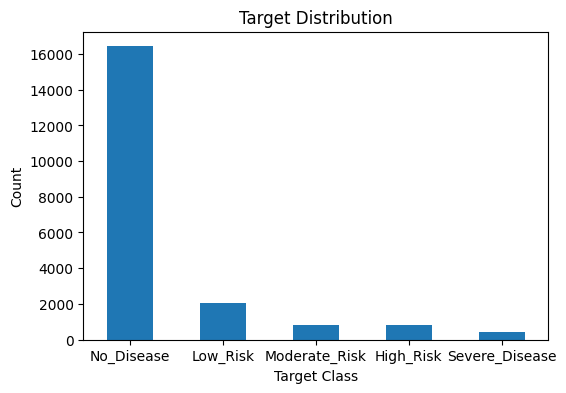

In [5]:
# Plot target distribution
plt.figure(figsize=(6, 4))
df['Target'].value_counts().plot(kind='bar')
plt.title('Target Distribution')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# Preprocessing 

In [6]:
# Clean Column Names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[^\w]+", "_", regex=True)
    .str.strip("_")
)

print(df.columns.tolist())

['age_of_the_patient', 'blood_pressure_mm_hg', 'specific_gravity_of_urine', 'albumin_in_urine', 'sugar_in_urine', 'red_blood_cells_in_urine', 'pus_cells_in_urine', 'pus_cell_clumps_in_urine', 'bacteria_in_urine', 'random_blood_glucose_level_mg_dl', 'blood_urea_mg_dl', 'serum_creatinine_mg_dl', 'sodium_level_meq_l', 'potassium_level_meq_l', 'hemoglobin_level_gms', 'packed_cell_volume', 'white_blood_cell_count_cells_cumm', 'red_blood_cell_count_millions_cumm', 'hypertension_yes_no', 'diabetes_mellitus_yes_no', 'coronary_artery_disease_yes_no', 'appetite_good_poor', 'pedal_edema_yes_no', 'anemia_yes_no', 'estimated_glomerular_filtration_rate_egfr', 'urine_protein_to_creatinine_ratio', 'urine_output_ml_day', 'serum_albumin_level', 'cholesterol_level', 'parathyroid_hormone_pth_level', 'serum_calcium_level', 'serum_phosphate_level', 'family_history_of_chronic_kidney_disease', 'smoking_status', 'body_mass_index_bmi', 'physical_activity_level', 'duration_of_diabetes_mellitus_years', 'duration_

In [7]:
# Clean Categorial Data
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip().str.lower()

In [8]:
# Target Column Transformation
print(df["target"].unique())

target_mapping = {
    'no_disease': 0,
    'low_risk': 1,
    'moderate_risk': 1,
    'high_risk': 1,
    'severe_disease': 1
}

df['target'] = df['target'].map(target_mapping)

print(df['target'].value_counts(dropna=False))

['no_disease' 'low_risk' 'moderate_risk' 'severe_disease' 'high_risk']
target
0    16432
1     4106
Name: count, dtype: int64


In [9]:
# Check Missing Values
print("Missing values beofre handling: ")
print(df.isnull().sum())

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include=["object"]).columns
df[cat_cols] = df[cat_cols].replace(["nan", "none"], pd.NA)
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

print("\nMissing values after handling: ")
print(df.isnull().sum())

Missing values beofre handling: 
age_of_the_patient                           0
blood_pressure_mm_hg                         0
specific_gravity_of_urine                    0
albumin_in_urine                             0
sugar_in_urine                               0
red_blood_cells_in_urine                     0
pus_cells_in_urine                           0
pus_cell_clumps_in_urine                     0
bacteria_in_urine                            0
random_blood_glucose_level_mg_dl             0
blood_urea_mg_dl                             0
serum_creatinine_mg_dl                       0
sodium_level_meq_l                           0
potassium_level_meq_l                        0
hemoglobin_level_gms                         0
packed_cell_volume                           0
white_blood_cell_count_cells_cumm            0
red_blood_cell_count_millions_cumm           0
hypertension_yes_no                          0
diabetes_mellitus_yes_no                     0
coronary_artery_disease_yes

In [10]:
# Standardize Column Names
df = df.rename(columns={
    "age_of_the_patient": "age",
    "blood_pressure_mm_hg": "bp",
    "specific_gravity_of_urine": "sg",
    "albumin_in_urine": "al",
    "sugar_in_urine": "su",
    "red_blood_cells_in_urine": "rbc",
    "blood_urea_mg_dl": "bu",
    "serum_creatinine_mg_dl": "sc",
    "sodium_level_meq_l": "sod",
    "potassium_level_meq_l": "pot",
    "hemoglobin_level_gms": "hemo",
    "white_blood_cell_count_cells_cumm": "wc",
    "red_blood_cell_count_millions_cumm": "rc",
    "hypertension_yes_no": "htn"
})

In [11]:
# Save Cleaned Dataset
PROCESSED_DATA_DIR = Path("../../data/cleaned/dataset_3")
os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)

df.to_csv(PROCESSED_DATA_DIR / "dataset_3_clean.csv", index=False)

print("Cleaned Dataset 3 saved to:", PROCESSED_DATA_DIR / "dataset_3_clean.csv")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Cleaned Dataset 3 saved to: ..\..\data\cleaned\dataset_3\dataset_3_clean.csv
Shape: (20538, 43)
Columns: ['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pus_cells_in_urine', 'pus_cell_clumps_in_urine', 'bacteria_in_urine', 'random_blood_glucose_level_mg_dl', 'bu', 'sc', 'sod', 'pot', 'hemo', 'packed_cell_volume', 'wc', 'rc', 'htn', 'diabetes_mellitus_yes_no', 'coronary_artery_disease_yes_no', 'appetite_good_poor', 'pedal_edema_yes_no', 'anemia_yes_no', 'estimated_glomerular_filtration_rate_egfr', 'urine_protein_to_creatinine_ratio', 'urine_output_ml_day', 'serum_albumin_level', 'cholesterol_level', 'parathyroid_hormone_pth_level', 'serum_calcium_level', 'serum_phosphate_level', 'family_history_of_chronic_kidney_disease', 'smoking_status', 'body_mass_index_bmi', 'physical_activity_level', 'duration_of_diabetes_mellitus_years', 'duration_of_hypertension_years', 'cystatin_c_level', 'urinary_sediment_microscopy_results', 'c_reactive_protein_crp_level', 'interleukin_6_il_6_level', 'target']
